# Photothermal Parameter Estimation: PINN vs Classical Methods

This notebook compares three methods for recovering the **heating rate** $a$ and **thermal time constant** $\tau$ from laser-induced $T(t)$ data of gold nanoparticle (GNP) suspensions:

1. **Roper** — log-linear fit to the cooling tail
2. **Whole-curve least squares** — global fit to the analytic ODE solution
3. **Physics-Informed Neural Network (PINN)** — data loss + embedded ODE residual

Experiments cover synthetic data (controlled ground truth) and five real heating–cooling curves digitised from three open-access papers.

In [1]:
import os
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')  # headless mode for scripts

import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import pandas as pd
from scipy.optimize import curve_fit

from network import Net, NetDiscovery, np_to_th, DEVICE
from diff_equations import grad, cooling_law

sns.set_theme()
torch.manual_seed(42)
torch.set_num_threads(4)

---
## 2 · Physical Model

### Governing ODE

$$\frac{dT}{dt} = a\,L(t) - \frac{T - T_{\mathrm{env}}}{\tau}$$

where $L(t) = 1$ while the laser is on ($t < t_{\mathrm{off}}$) and $L(t) = 0$ afterwards, $a$ (°C/s) is the effective heating rate, and $\tau$ (s) is the thermal time constant. Throughout, $\theta = T - T_{\mathrm{env}}$ denotes the temperature rise above ambient.

### Analytic solution

$$T(t) = T_{\mathrm{env}} + \begin{cases}a\tau\!\left(1 - e^{-t/\tau}\right) & t < t_{\mathrm{off}} \\a\tau\!\left(1 - e^{-t_{\mathrm{off}}/\tau}\right)e^{-(t-t_{\mathrm{off}})/\tau} & t \ge t_{\mathrm{off}}\end{cases}$$

### Roper bias

The Roper method estimates $\hat\tau$ from the cooling tail and sets $\hat a = \Delta T_{\max}/\hat\tau$, which assumes $\Delta T_{\max} = a\tau$ (steady state). Because $\Delta T_{\max} = a\tau\,(1 - e^{-t_{\mathrm{off}}/\tau})$,

$$\frac{\hat a}{a} = \frac{\tau}{\hat\tau}\,\bigl(1 - e^{-t_{\mathrm{off}}/\tau}\bigr).$$

The second factor is the heating-truncation bias. With an exact cooling fit ($\hat\tau = \tau$) the bias is $-e^{-t_{\mathrm{off}}/\tau}$: $\approx -37\,\%$ at $t_{\mathrm{off}}/\tau = 1$ and $\approx -0.7\,\%$ at $t_{\mathrm{off}}/\tau = 5$. The first factor departs from one when the cooling phase alone does not follow the relaxation time of the complete trace, which is what happens on the real curves of Section 10.

---
## 3 · Analytic Solution and Synthetic Data

**`heating_cooling(t, a, tau, t_off, Tenv)`** — exact solution of $d\theta/dt = a\,L(t) - \theta/\tau$ (Section 2)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | times at which the temperature is evaluated (array) |
| `a` | $a$ | °C/s | heating rate |
| `tau` | $\tau$ | s | thermal time constant |
| `t_off` | $t_{\mathrm{off}}$ | s | laser switch-off time |
| `Tenv` | $T_{\mathrm{env}}$ | °C | ambient temperature (default 25) |

**Returns:** the temperature $T(t)$ in °C.

In [2]:
def heating_cooling(t, a, tau, t_off, Tenv=25.0):
    """Exact analytic solution of the photothermal ODE."""
    theta_off = a * tau * (1 - np.exp(-t_off / tau))
    return Tenv + np.where(
        t < t_off,
        a * tau * (1 - np.exp(-t / tau)),
        theta_off * np.exp(-(t - t_off) / tau),
    )

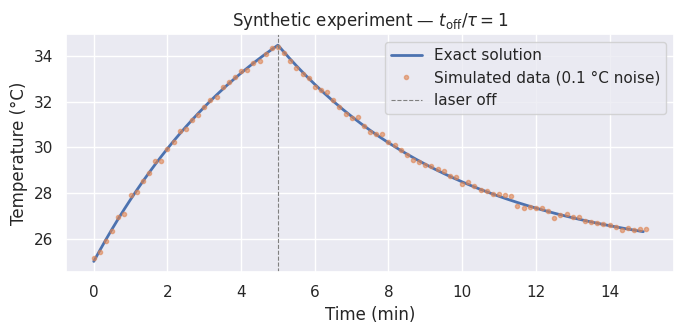

In [3]:
# True parameter values (to be recovered by each method)
np.random.seed(1)
Tenv_true  = 25.0    # ambient temperature [°C]
a_true     = 0.05    # heating rate [°C/s]
tau_true   = 300.0   # thermal time constant [s]
t_off_true = 1 * tau_true # laser switch-off time [s]  (short experiment: t_off/τ = 1)

times = np.arange(0, 3 * tau_true, 5)
eq    = functools.partial(heating_cooling, a=a_true, tau=tau_true, t_off=t_off_true, Tenv=Tenv_true)
temps = eq(times)

# Training data: 10 s sampling interval, 0.1 °C Gaussian noise
t = np.arange(0, 3 * tau_true + 5, 10)
T = eq(t) + 0.1 * np.random.randn(len(t))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(times / 60, temps, lw=2, label='Exact solution')
ax.plot(t / 60, T, 'o', ms=3, alpha=0.6, label='Simulated data (0.1 °C noise)')
ax.axvline(t_off_true / 60, color='gray', ls='--', lw=0.8, label='laser off')
ax.set_xlabel('Time (min)'); ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Synthetic experiment — $t_{{\\mathrm{{off}}}}/\\tau = {t_off_true/tau_true:.0f}$')
ax.legend()
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig0_synthetic_data.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 4 · Classical Baselines

### 4.1 Roper method

Estimates $\tau$ from the log-linear slope of the cooling phase, then computes
$\hat{a} = \Delta T_{\max} / \hat{\tau}$.

### 4.2 Whole-curve least-squares

Fits the exact analytic solution (heating + cooling) to all data points via `scipy.optimize.curve_fit`, with $T_{\mathrm{env}}$ fixed.

**`roper(t, T, t_off, Tenv_, min_frac)`** — Roper method: $\ln\theta$ is fitted on the cooling tail to get $\hat\tau$, then $\hat a = \Delta T_{\max}/\hat\tau$ (Section 4)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | measured times (array) |
| `T` | $T$ | °C | measured temperatures (array) |
| `t_off` | $t_{\mathrm{off}}$ | s | laser switch-off time |
| `Tenv_` | $T_{\mathrm{env}}$ | °C | ambient temperature, subtracted to get $\theta = T - T_{\mathrm{env}}$ |
| `min_frac` | — | — | cooling points are used while $\theta > \texttt{min\_frac}\cdot\Delta T_{\max}$ (default 0.05) |

**Returns:** `(a_est, tau_est)` in °C/s and s.

In [4]:
def roper(t, T, t_off, Tenv_=Tenv_true, min_frac=0.05):
    """Standard Roper et al. 2007 method."""
    theta  = T - Tenv_
    dT_max = theta[t <= t_off].max()
    cool   = (t > t_off) & (theta > min_frac * dT_max)
    slope, _ = np.polyfit(t[cool] - t_off, np.log(theta[cool]), 1)
    tau_est  = -1.0 / slope
    return dT_max / tau_est, tau_est

**`whole_curve_fit(t, T, t_off, Tenv_)`** — least-squares fit of `heating_cooling` to all points, $\min_{a,\tau}\sum_i (T_i - T_{\mathrm{model}}(t_i; a, \tau))^2$ (Section 4)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | measured times (array) |
| `T` | $T$ | °C | measured temperatures (array) |
| `t_off` | $t_{\mathrm{off}}$ | s | laser switch-off time (fixed, not fitted) |
| `Tenv_` | $T_{\mathrm{env}}$ | °C | ambient temperature (fixed, not fitted) |

**Returns:** `(a_est, tau_est)` in °C/s and s. Fit bounds: $a \in [10^{-6}, 10]$, $\tau \in [1, 10^5]$; start values $a = 0.01$, $\tau = 100$.

In [5]:
def whole_curve_fit(t, T, t_off, Tenv_=Tenv_true):
    """Least-squares fit to the full analytic ODE solution."""
    f = lambda t_, a_, tau_: heating_cooling(t_, a_, tau_, t_off, Tenv_)
    (a_est, tau_est), _ = curve_fit(f, t, T, p0=(0.01, 100.0),
                                    bounds=([1e-6, 1.0], [10.0, 1e5]))
    return a_est, tau_est

In [6]:
a_r,  tau_r  = roper(t, T, t_off_true)
a_wc, tau_wc = whole_curve_fit(t, T, t_off_true)

print(f"True values :  a = {a_true:.4f} °C/s    τ = {tau_true:.0f} s")
print(f"Roper       :  a = {a_r:.4f} °C/s  ({100*(a_r-a_true)/a_true:+.1f} %)    τ = {tau_r:.0f} s")
print(f"Whole-curve :  a = {a_wc:.4f} °C/s  ({100*(a_wc-a_true)/a_true:+.1f} %)    τ = {tau_wc:.0f} s")

True values :  a = 0.0500 °C/s    τ = 300 s
Roper       :  a = 0.0311 °C/s  (-37.9 %)    τ = 303 s
Whole-curve :  a = 0.0498 °C/s  (-0.5 %)    τ = 302 s


---
## 5 · Physics-Informed Neural Network (PINN)

### 5.1 Architecture and scaling

The network is a 4-hidden-layer MLP (100 units each, **tanh** activations). For stable training, time and temperature rise are scaled to about $[0, 1]$:

$$\hat t = \frac{t}{t_{\mathrm{scale}}}, \qquad \hat\theta = \frac{\theta}{T_{\mathrm{scale}}}, \qquad t_{\mathrm{scale}} = \max t, \quad T_{\mathrm{scale}} = \max\theta,$$

and the network maps the input

$$\mathbf{x}(\hat t) = \bigl[\,\hat t,\;\mathrm{ReLU}(\hat t - \hat t_{\mathrm{off}})\,\bigr], \qquad \hat t_{\mathrm{off}} = t_{\mathrm{off}}/t_{\mathrm{scale}},$$

to the scaled temperature rise $\hat\theta(\hat t)$. The second input channel encodes the laser switch-off corner, which a smooth network struggles to represent with a single input (Section 8).

Two scalar parameters are learned alongside the weights; both are in scaled units and are converted back after training:

| Symbol | Code | Meaning | Back to physical units |
|---|---|---|---|
| $\hat a$ | `model.a` | scaled heating rate | $a = \hat a\,T_{\mathrm{scale}}/t_{\mathrm{scale}}$ |
| $\hat\kappa$ | `model.kappa` | scaled loss rate (the linear loss $\theta/\tau$ in scaled units) | $\tau = t_{\mathrm{scale}}/\hat\kappa$ |

The scaled ODE is $d\hat\theta/d\hat t = \hat a\,L - \hat\kappa\,\hat\theta$. Note that $\hat\kappa$ exists only for the linear loss; the effective loss rate $r(\theta) = f(\theta)/\theta$ of Section 11 is a different, unscaled quantity.

### 5.2 Loss function

$$\mathcal{L} = \underbrace{\frac{1}{N}\sum_i \bigl(\hat\theta(\hat t_i) - \hat\theta^{\mathrm{obs}}_i\bigr)^2}_{\text{data}} + \lambda\biggl[\underbrace{\frac{1}{M}\sum_j \left(\hat a\,L(\hat t_j) - \hat\kappa\,\hat\theta(\hat t_j) - \frac{d\hat\theta}{d\hat t}\bigl|_{\hat t_j}\right)^2}_{\text{physics (ODE residual)}} + \underbrace{\hat\theta(0)^2}_{\text{initial condition}}\biggr]$$

where $\hat\theta^{\mathrm{obs}}_i$ are the scaled observations, the $M = 800$ collocation times $\hat t_j$ are spread evenly over $[0, 1]$ (`t_col` in the code), and $\lambda = 1$.

### 5.3 Optimisation

1. **Adam** — 3 000 steps at learning rate $\alpha = 3\times10^{-3}$ (input scaling enables a large learning rate)
2. **L-BFGS** — 300 iterations with strong Wolfe line search (final convergence to high precision)

### 5.4 Code names used in the notebook

| Math | Code |
|---|---|
| $t_{\mathrm{scale}},\; T_{\mathrm{scale}}$ | `t_scale`, `T_scale` |
| $\hat t,\; \hat\theta^{\mathrm{obs}}$ (scaled data) | `t_hat`, `theta_hat` |
| $\hat t_{\mathrm{off}}$ | `t_off_hat` |
| collocation times $\hat t_j$ | `t_col` |
| true parameters of the synthetic data | globals `a_true`, `tau_true`, `Tenv_true`, `t_off_true` |
| fitted values | `a_est`, `tau_est`, or `a_`, `tau_` inside loops |

A trailing underscore (`t_off_`, `Tenv_`, `T_`) only marks a function argument that would otherwise shadow one of the globals.

**`PhotothermalPINN(t_off_hat, switch_input, ...)`** — network for the linear loss (Section 5): $\hat t \mapsto \hat\theta$, with learnable $\hat a$ (`a`) and $\hat\kappa$ (`kappa`)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t_off_hat` | $\hat t_{\mathrm{off}}$ | — | scaled switch-off time, $t_{\mathrm{off}}/t_{\mathrm{scale}}$ |
| `switch_input` | — | — | `True`: inputs $[\hat t, \mathrm{ReLU}(\hat t - \hat t_{\mathrm{off}})]$; `False`: only $\hat t$ |
| `n_units` | — | — | neurons per hidden layer (default 100; 4 hidden layers, tanh) |
| `epochs` | — | — | Adam steps in `fit` (default 3000) |
| `lr` | $\alpha$ | — | Adam learning rate (default $3\times10^{-3}$) |
| `loss` | — | — | data loss (default MSE) |
| `loss2`, `loss2_weight` | physics term, $\lambda$ | — | extra loss `loss2(model)` (ODE residual + initial condition) and its weight (default 1) |

**Forward:** takes $\hat t$ of shape (N, 1) and returns $\hat\theta$ of shape (N, 1).

In [7]:
class PhotothermalPINN(NetDiscovery):
    """PINN for discovering (a, τ) from photothermal heating–cooling data."""

    def __init__(self, t_off_hat, switch_input=True,
                 n_units=100, epochs=3000, loss=nn.MSELoss(),
                 lr=3e-3, loss2=None, loss2_weight=1.0):
        n_in = 2 if switch_input else 1
        super().__init__(input_dim=n_in, output_dim=1,
                         n_units=n_units, epochs=epochs,
                         loss=loss, lr=lr,
                         loss2=loss2, loss2_weight=loss2_weight)

        # Replace ReLU activations with tanh for smooth ODE gradients
        for i, layer in enumerate(self.layers):
            if isinstance(layer, nn.ReLU):
                self.layers[i] = nn.Tanh()

        self.t_off_hat    = t_off_hat
        self.switch_input = switch_input
        self.a            = nn.Parameter(data=torch.tensor([0.]))

    def forward(self, t):
        if self.switch_input:
            t = torch.cat([t, torch.relu(t - self.t_off_hat)], dim=1)
        return self.out(self.layers(t))

**`train_photothermal(t_, T_, t_off_, Tenv_, switch_input, lam, adam_epochs, lbfgs_iters, seed)`** — scales the data, trains `PhotothermalPINN` with the loss of Section 5.2, converts back with $a = \hat a\,T_{\mathrm{scale}}/t_{\mathrm{scale}}$, $\tau = t_{\mathrm{scale}}/\hat\kappa$

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t_` | $t$ | s | measured times (array) |
| `T_` | $T$ | °C | measured temperatures (array) |
| `t_off_` | $t_{\mathrm{off}}$ | s | laser switch-off time |
| `Tenv_` | $T_{\mathrm{env}}$ | °C | ambient temperature |
| `switch_input` | — | — | use the switch input (default `True`) |
| `lam` | $\lambda$ | — | weight of the physics terms (default 1) |
| `adam_epochs`, `lbfgs_iters` | — | — | Adam steps (3000) and L-BFGS iterations (300) |
| `seed` | — | — | random seed for the weights |

**Returns:** `(a_est, tau_est)` in °C/s and s. The physics residual uses $M = 800$ collocation times `t_col` in $[0, 1]$.

In [8]:
def train_photothermal(t_, T_, t_off_, Tenv_=Tenv_true,
                       switch_input=True, lam=1.0,
                       adam_epochs=3000, lbfgs_iters=300, seed=0):
    """Train PhotothermalPINN and return (a_est, tau_est)."""
    torch.manual_seed(seed)

    # Normalise inputs to [0, 1]
    t_scale = float(t_.max())
    T_scale = float(max((T_ - Tenv_).max(), 1e-3))
    t_hat, theta_hat = t_ / t_scale, (T_ - Tenv_) / T_scale
    t_off_hat    = t_off_ / t_scale

    def phys_loss(model):
        t_col = torch.linspace(0, 1, 800).view(-1, 1).requires_grad_(True).to(DEVICE)
        laser = (t_col < t_off_hat).float()
        temps = model(t_col)
        dT    = grad(temps, t_col)[0]
        pde   = model.a * laser - model.kappa * temps - dT
        ic    = model(torch.zeros(1, 1).to(DEVICE)).pow(2).mean()
        return torch.mean(pde ** 2) + ic

    model = PhotothermalPINN(t_off_hat, switch_input=switch_input,
                              loss2=phys_loss, loss2_weight=lam,
                              epochs=adam_epochs, lr=3e-3).to(DEVICE)   # same device as the data
    model.fit(t_hat.reshape(-1, 1), theta_hat.reshape(-1, 1))

    # L-BFGS fine-tuning
    Xt_ = np_to_th(t_hat.reshape(-1, 1))
    yt_ = np_to_th(theta_hat.reshape(-1, 1))
    opt = torch.optim.LBFGS(model.parameters(), lr=1.0,
                              max_iter=lbfgs_iters, line_search_fn='strong_wolfe')
    def _closure():
        opt.zero_grad()
        l = model.loss(yt_, model(Xt_)) + lam * phys_loss(model)
        l.backward()
        return l
    opt.step(_closure)

    return model.a.item() * T_scale / t_scale, t_scale / model.kappa.item()

---
## 6 · Sanity Check — Noiseless Full-Duration Experiment

With zero noise and $t_{\mathrm{off}} = 5\tau$, the whole-curve fit and the PINN recover the true parameters to within 0.05 %, while Roper keeps its heating-truncation bias $-e^{-5} \approx -0.7\,\%$.

In [9]:
t_sc, T_sc = (
    lambda t_e: (t_e, functools.partial(heating_cooling, a=a_true, tau=tau_true, t_off=5*tau_true, Tenv=Tenv_true)(t_e))
)(np.arange(0, 7 * tau_true, 10))

print(f"True:          a = {a_true:.4f}  τ = {tau_true:.0f} s")
for name, fn in [
    ('Roper',           lambda: roper(t_sc, T_sc, 5*tau_true)),
    ('Whole-curve fit', lambda: whole_curve_fit(t_sc, T_sc, 5*tau_true)),
    ('PINN + switch',   lambda: train_photothermal(t_sc, T_sc, 5*tau_true)),
]:
    a_, tau_ = fn()
    print(f"{name:22s}   a = {a_:.4f} ({100*(a_-a_true)/a_true:+.1f}%)   τ = {tau_:.0f} s ({100*(tau_-tau_true)/tau_true:+.1f}%)")

True:          a = 0.0500  τ = 300 s
Roper                    a = 0.0497 (-0.7%)   τ = 300 s (-0.0%)
Whole-curve fit          a = 0.0500 (-0.0%)   τ = 300 s (+0.0%)


/home/reza/miniconda3/envs/pinns/lib/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/3000, loss: 0.46
Epoch 300/3000, loss: 0.18
Epoch 600/3000, loss: 0.16
Epoch 900/3000, loss: 0.12
Epoch 1200/3000, loss: 0.09
Epoch 1500/3000, loss: 0.07
Epoch 1800/3000, loss: 0.06
Epoch 2100/3000, loss: 0.05
Epoch 2400/3000, loss: 0.04
Epoch 2700/3000, loss: 0.03
PINN + switch            a = 0.0500 (-0.0%)   τ = 300 s (+0.0%)


---
## 7 · Experiment 1 — Full vs Short Heating Duration

Same nanoparticle, same noise level (0.1 °C), different laser-on duration.

| Experiment | $t_{\mathrm{off}}$ | $t_{\mathrm{off}}/\tau$ |
|---|---|---|
| Full | $5\tau = 1500$ s | 5 |
| Short | $1\tau = 300$ s | 1 |

**`make_experiment(t_off_e, t_end, dt, noise, seed)`** — synthetic noisy experiment from `heating_cooling` with the true values `a_true`, `tau_true`, `Tenv_true`

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t_off_e` | $t_{\mathrm{off}}$ | s | laser switch-off time |
| `t_end` | — | s | end time of the record |
| `dt` | — | s | sampling interval (default 10) |
| `noise` | — | °C | standard deviation of the Gaussian noise (default 0.1) |
| `seed` | — | — | random seed of the noise |

**Returns:** `(t_e, T_e)` — times and noisy temperatures.

In [10]:
def make_experiment(t_off_e, t_end, dt=10, noise=0.1, seed=0):
    rng = np.random.default_rng(seed)
    t_e = np.arange(0, t_end + dt / 2, dt)
    T_e = functools.partial(heating_cooling, a=a_true, tau=tau_true, t_off=t_off_e, Tenv=Tenv_true)(t_e)
    return t_e, T_e + rng.normal(0, noise, len(t_e))

EXPERIMENTS = {
    "full  (heat 5τ, cool 5τ)":  dict(t_off_e=5 * tau_true, t_end=10 * tau_true),
    "short (heat 1τ, cool 2τ)": dict(t_off_e=1 * tau_true, t_end= 3 * tau_true),
}

In [11]:
METHODS = {
    "Roper":           roper,
    "whole-curve fit": whole_curve_fit,
    "PINN (no switch)": lambda t_, T_, to: train_photothermal(t_, T_, to, switch_input=False),
    "PINN + switch":    lambda t_, T_, to: train_photothermal(t_, T_, to, switch_input=True),
}

rows, fits = [], {}
for exp_name, e in EXPERIMENTS.items():
    te, Te = make_experiment(**e, seed=1)
    for m_name, fn in METHODS.items():
        a_, tau_ = fn(te, Te, e['t_off_e'])
        fits[(exp_name, m_name)] = (a_, tau_)
        rows.append(dict(experiment=exp_name, method=m_name,
                         a_err=round(100 * (a_ - a_true) / a_true, 1),
                         tau_err=round(100 * (tau_ - tau_true) / tau_true, 1)))

df1 = pd.DataFrame(rows)
print("=== Error in a [%] ===")
print(df1.pivot(index='method', columns='experiment', values='a_err').to_string())

Epoch 0/3000, loss: 0.30
Epoch 300/3000, loss: 0.21
Epoch 600/3000, loss: 0.18
Epoch 900/3000, loss: 0.15
Epoch 1200/3000, loss: 0.13
Epoch 1500/3000, loss: 0.12
Epoch 1800/3000, loss: 0.10
Epoch 2100/3000, loss: 0.23
Epoch 2400/3000, loss: 0.09
Epoch 2700/3000, loss: 0.08
Epoch 0/3000, loss: 0.32
Epoch 300/3000, loss: 0.20
Epoch 600/3000, loss: 0.16
Epoch 900/3000, loss: 0.12
Epoch 1200/3000, loss: 0.10
Epoch 1500/3000, loss: 0.08
Epoch 1800/3000, loss: 0.07
Epoch 2100/3000, loss: 0.36
Epoch 2400/3000, loss: 0.06
Epoch 2700/3000, loss: 0.06
Epoch 0/3000, loss: 0.20
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.06
Epoch 1200/3000, loss: 0.05
Epoch 1500/3000, loss: 0.04
Epoch 1800/3000, loss: 0.03
Epoch 2100/3000, loss: 0.03
Epoch 2400/3000, loss: 0.16
Epoch 2700/3000, loss: 0.03
Epoch 0/3000, loss: 0.22
Epoch 300/3000, loss: 0.10
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000,

### Figure 1 — Fitted curves on the short experiment

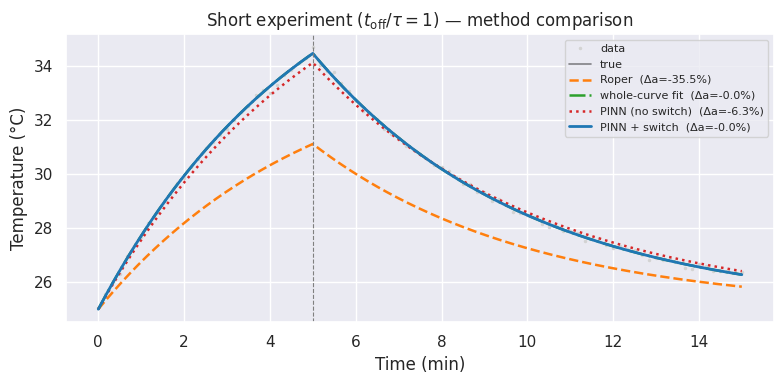

In [12]:
e_sh = EXPERIMENTS["short (heat 1τ, cool 2τ)"]
t_sh, T_sh = make_experiment(**e_sh, seed=1)
tt = np.linspace(0, t_sh.max(), 1000)

styles = {
    "Roper":           dict(color='tab:orange', ls='--', lw=1.8),
    "whole-curve fit": dict(color='tab:green',  ls='-.', lw=1.8),
    "PINN (no switch)": dict(color='tab:red',   ls=':',  lw=1.8),
    "PINN + switch":   dict(color='tab:blue',   ls='-',  lw=2.0),
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_sh / 60, T_sh, '.', ms=3, color='lightgray', zorder=1, label='data')
ax.plot(tt / 60, eq(tt), 'k-', lw=1.2, alpha=0.5, label='true')

for m_name, sty in styles.items():
    a_e, tau_e = fits[("short (heat 1τ, cool 2τ)", m_name)]
    err = 100 * (a_e - a_true) / a_true
    ax.plot(tt / 60,
            heating_cooling(tt, a_e, tau_e, e_sh['t_off_e'], Tenv_true),
            label=f'{m_name}  (Δa={err:+.1f}%)', **sty)

ax.axvline(e_sh['t_off_e'] / 60, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(r'Short experiment ($t_{\mathrm{off}}/\tau = 1$) — method comparison')
ax.legend(fontsize=8)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig1_short_experiment.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 8 · Why the Switch Input Matters

A smooth MLP struggles to represent the sharp corner in $T(t)$ at $t_{\mathrm{off}}$ with a single scalar input $t$.  
Adding $\mathrm{ReLU}(t - t_{\mathrm{off}})$ as a second input provides the network with an explicit signal at the kink. Without it, the error in $a$ over five initialisation seeds spans −29.3 % to +10.0 % on the long experiment and −6.3 % to +0.14 % on the short one (Section 8.1); with it, every run stays within 0.7 %.

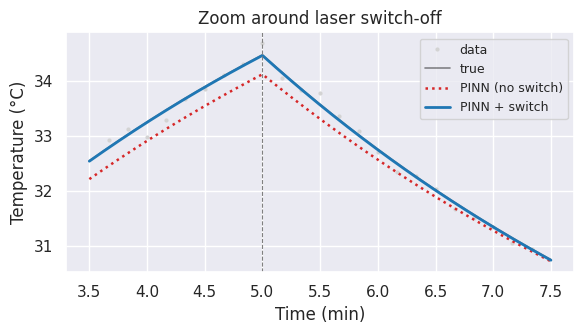

In [13]:
zoom_lo = 0.7 * e_sh['t_off_e']
zoom_hi = 1.5 * e_sh['t_off_e']
tt_w    = np.linspace(zoom_lo, zoom_hi, 600)
mask    = (t_sh > zoom_lo) & (t_sh < zoom_hi)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_sh[mask] / 60, T_sh[mask], '.', ms=4, color='lightgray', label='data')
ax.plot(tt_w / 60, eq(tt_w), 'k-', lw=1.2, alpha=0.5, label='true')

for key in ['PINN (no switch)', 'PINN + switch']:
    a_e, tau_e = fits[("short (heat 1τ, cool 2τ)", key)]
    ax.plot(tt_w / 60,
            heating_cooling(tt_w, a_e, tau_e, e_sh['t_off_e'], Tenv_true),
            label=key, **styles[key])

ax.axvline(e_sh['t_off_e'] / 60, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Zoom around laser switch-off')
ax.legend(fontsize=9)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig2_switch_zoom.jpg', dpi=150, bbox_inches='tight')
plt.show()


### 8.1 Is the switch effect reproducible?

Section 7 trains each network once. Here the linear-loss PINN is trained five times on the same data (noise seed 1, as in Section 7), with and without the switch input, changing only the initialisation seed. The errors are saved in `results/switch_ablation.csv`.

**Result.** Without the switch input the error in $a$ spans −29.3 % to +10.0 % (long experiment, SD 17.1 %) and −6.3 % to +0.14 % (short, SD 2.8 %); the same seed gives different errors on different hardware, so the unswitched network is not reproducible. With the switch input all ten runs stay within 0.7 % (SD 0.32 % and 0.02 %).

In [14]:
# Section 8.1: same data as Section 7, five initialisation seeds, with and without the switch input
from contextlib import redirect_stdout
import io

abl_rows = []
for exp_name, e in EXPERIMENTS.items():
    te, Te = make_experiment(**e, seed=1)
    for switch in (False, True):
        for seed_ in range(5):
            with redirect_stdout(io.StringIO()):          # hide the per-epoch log
                a_, tau_ = train_photothermal(te, Te, e['t_off_e'], switch_input=switch, seed=seed_)
            abl_rows.append(dict(experiment=exp_name, switch=switch, seed=seed_,
                                 a_err_pct=100 * (a_ - a_true) / a_true,
                                 tau_err_pct=100 * (tau_ - tau_true) / tau_true))

df_abl = pd.DataFrame(abl_rows)
os.makedirs("results", exist_ok=True)
df_abl.to_csv("results/switch_ablation.csv", index=False)
print("=== Error in a [%] over five initialisation seeds (same data) ===")
print(df_abl.groupby(['experiment', 'switch'])['a_err_pct'].agg(['mean', 'std', 'min', 'max']).round(2).to_string())

=== Error in a [%] over five initialisation seeds (same data) ===
                                 mean    std    min    max
experiment               switch                           
full  (heat 5τ, cool 5τ) False  -4.66  17.05 -29.31  10.03
                         True   -0.11   0.32  -0.65   0.18
short (heat 1τ, cool 2τ) False  -1.31   2.80  -6.33   0.14
                         True   -0.04   0.02  -0.06  -0.01


---
## 9 · Systematic Sweep — Error vs Heating Duration

Heating time varied from $0.5\tau$ to $5\tau$ (cooling always $2\tau$). Two random seeds per condition.

In [15]:
rows2 = []
for heat_tau in [0.5, 1.0, 2.0, 5.0]:
    t_off_ = heat_tau * tau_true
    for seed_ in range(2):
        te_, Te_ = make_experiment(t_off_, t_off_ + 2 * tau_true, seed=100 + seed_)
        for m_name, fn in [
            ('Roper',           roper),
            ('whole-curve fit', whole_curve_fit),
            ('PINN + switch',   lambda t_, T_, to: train_photothermal(t_, T_, to)),
        ]:
            a_, _ = fn(te_, Te_, t_off_)
            rows2.append(dict(heat_tau=heat_tau, method=m_name,
                              a_error=100 * (a_ - a_true) / a_true))

df2 = pd.DataFrame(rows2)
os.makedirs("results", exist_ok=True)
df2.to_csv("results/photothermal_sweep.csv", index=False)

pivot2 = df2.groupby(['heat_tau', 'method'])['a_error'].mean().unstack()
print("=== Mean error in a [%] ===")
print(pivot2.round(1).to_string())

Epoch 0/3000, loss: 0.21
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.06
Epoch 1200/3000, loss: 0.04
Epoch 1500/3000, loss: 0.03
Epoch 1800/3000, loss: 0.02
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.03
Epoch 2700/3000, loss: 0.01
Epoch 0/3000, loss: 0.22
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.06
Epoch 1200/3000, loss: 0.05
Epoch 1500/3000, loss: 0.03
Epoch 1800/3000, loss: 0.03
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.01
Epoch 0/3000, loss: 0.23
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000, loss: 0.02
Epoch 2100/3000, loss: 0.01
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.00
Epoch 0/3000, loss: 0.24
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000,

### Figure 2 — Error in $a$ vs $t_{\mathrm{off}}/\tau$

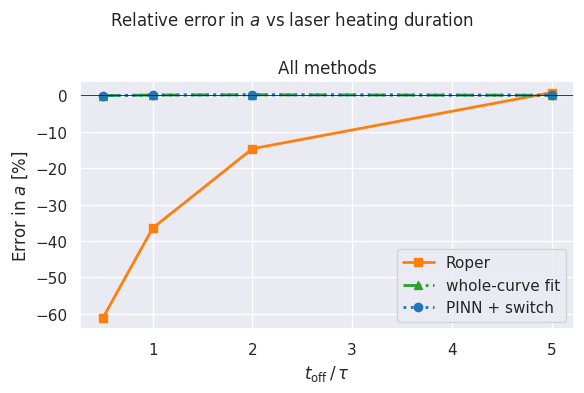

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

styles2 = {
    'Roper':           dict(color='tab:orange', marker='s', ls='-',  lw=2),
    'whole-curve fit': dict(color='tab:green',  marker='^', ls='-.', lw=2),
    'PINN + switch':   dict(color='tab:blue',   marker='o', ls=':',  lw=2),
}

for m, sty in styles2.items():
    ax.plot(pivot2.index, pivot2[m], label=m, **sty)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel(r'$t_{\mathrm{off}}\,/\,\tau$')
ax.set_ylabel('Error in $a$ [%]')
ax.set_title('All methods')
ax.legend()

plt.suptitle(r'Relative error in $a$ vs laser heating duration', fontsize=12)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig3_error_sweep.jpg', dpi=150, bbox_inches='tight')
plt.show()

---
## 10 · Validation on Real Experimental Data

### 10.1 Data sources

We searched PubMed Central (PMC) for open-access articles that:
1. Report full heating **and** cooling phases in a single figure
2. Use gold nanoparticles under CW laser irradiation
3. Provide $t_{\mathrm{off}}$ and $T_{\mathrm{env}}$ without ambiguity

All papers are published under **CC BY 4.0** (figure digitisation permitted).

| Dataset | Paper | Figure | PMC ID |
|---|---|---|---|
| GNR 10×38 nm, 808 nm laser | Vikas et al., *Beilstein J. Nanotechnol.* **14**, 205 (2023) | Fig. 6(g) | PMC9924363 |
| GNR 10×41 nm (bare + PEG), 808 nm | Sánchez López de Pablo et al., *Nanoscale Res. Lett.* **9**, 441 (2014) | Fig. 6 | PMC4155392 |
| AuNR and AuNR@Si, 785 nm | Armenta-Gamez et al., *Pharmaceutics* **18**, 310 (2026) | Fig. 4A | PMC13028931 |

See `real_data/SOURCES.md` for full BibTeX citations.

---

### 10.2 Digitisation

Figures were downloaded from the open-access article pages (PMC, MDPI) and digitised with a Python script (Pillow + NumPy): the axes are calibrated from the major tick marks by a linear fit, each curve is extracted as the per-column centroid of its colour, the time origin is moved to the laser switch-on, and the result is linearly interpolated onto a 10 s grid. **No smoothing and no model fit are applied**, so every deviation from the single-$\tau$ ODE in the original figure is kept.

| Error source | Estimate |
|---|---|
| Line centroid / pixel size | ±0.05–0.13 °C, ±2.5–6.6 s (one pixel) |
| Axis calibration (tick-fit residual) | below one pixel (≤ 0.03 °C, ≤ 4.4 s) |
| Switch-on and switch-off times | ±1 pixel column (2.5–6.6 s) |

**Re-check (2026-10-04).** An independent re-digitisation of all five curves from the original figure images (same tick-mark calibration, per-column colour centroid) reproduces the CSV files with an RMS difference of 0.02–0.04 °C (largest single difference 0.06–0.22 °C, near-vertical switch-off segments excluded); the error estimates above are the values measured in that check.

Notes: the tick labelled "35" in Armenta-Gamez Fig. 4A sits at the 30-min position (uniform tick spacing). The bare-GNR baseline is hidden under the other curves, so its switch-on time is taken from the PEG-GNR curve of the same figure. Armenta-Gamez et al. state 25 min of irradiation. On the figure's time axis the laser goes off at 25.4 min (AuNR) and 24.2 min (AuNR@Si), close to that value, but it is switched on at 3.0 and 3.3 min, so the irradiation lasts 22.5 and 20.9 min; this is the $t_{\mathrm{off}}$ used here. A uniform error in the time axis would rescale $a$ and $\tau$ by the same factor and leave $t_{\mathrm{off}}/\tau$, every relative change of $a$ and every residual unchanged (checked with the least-squares fits; the PINN works in $t/t_{\max}$ and is exactly invariant).

---

### 10.3 Experimental conditions

| Dataset | Nanoparticle | Conc. | Laser | $t_{\mathrm{off}}$ (s) | $T_{\mathrm{env}}$ (°C) | $t_{\mathrm{off}}/\tau$ |
|---|---|---|---|---|---|---|
| Vikas 2023 | GNR 10×38 nm | 20 µg/mL | 808 nm CW diode | 900 | 25.0 (ΔT data) | **2.4** |
| Sánchez 2014 — bare GNR | GNR 10×41 nm | 36 µg/mL | 808 nm, 2 W CW | 1799 | 25.47 | **7.9** |
| Sánchez 2014 — PEG-GNR | GNR 10×41 nm (PEG) | 36 µg/mL | 808 nm, 2 W CW | 1799 | 25.34 | **8.2** |
| Armenta-Gamez 2026 — AuNR | AuNR bare | 50 µg/mL | 785 nm, 1.2 W/cm² CW | 1347 | 23.85 | **3.6** |
| Armenta-Gamez 2026 — AuNR@Si | AuNR in mesoporous silica | 50 µg/mL | 785 nm, 1.2 W/cm² CW | 1255 | 24.15 | **5.7** |

$\tau$ in the last column is the whole-curve reference value used below.

In [17]:
import os

REAL_DATA_DIR = "real_data"

# t_off and Tenv come from the digitised curves (time origin at laser switch-on);
# ref_a and ref_tau are the whole-curve least-squares fit, used as the reference on real data.
REAL_DATASETS = {
    "Vikas 2023\nGNR 10×38 nm, 808 nm": dict(
        file      = os.path.join(REAL_DATA_DIR, "gnr_10x38_20ugml_NIR_laser.csv"),
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=900.0, Tenv=25.0, ref_a=0.04561, ref_tau=381.0,
    ),
    "Sánchez 2014\nB-GNR 10×41 nm, 808 nm": dict(
        file        = os.path.join(REAL_DATA_DIR, "gnr_10x41_peg_bare_808nm_2W.csv"),
        nanoparticle= "B-GNR_10x41nm_808nm_2W",
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=1799.2, Tenv=25.47, ref_a=0.08740, ref_tau=228.4,
    ),
    "Sánchez 2014\nPEG-GNR 10×41 nm, 808 nm": dict(
        file        = os.path.join(REAL_DATA_DIR, "gnr_10x41_peg_bare_808nm_2W.csv"),
        nanoparticle= "PEG-GNR_10x41nm_808nm_2W",
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=1799.2, Tenv=25.34, ref_a=0.11486, ref_tau=220.2,
    ),
    "Armenta-Gamez 2026\nAuNR, 785 nm": dict(
        file      = os.path.join(REAL_DATA_DIR, "aunr_785nm_1p2Wcm2_pmc13028931.csv"),
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=1347.4, Tenv=23.85, ref_a=0.10533, ref_tau=377.0,
    ),
    "Armenta-Gamez 2026\nAuNR@Si, 785 nm": dict(
        file      = os.path.join(REAL_DATA_DIR, "aunrsi_785nm_1p2Wcm2_pmc13028931.csv"),
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=1255.1, Tenv=24.15, ref_a=0.09278, ref_tau=220.9,
    ),
}

def load_real(ds):
    df = pd.read_csv(ds["file"])
    if "nanoparticle" in ds:
        df = df[df["nanoparticle"] == ds["nanoparticle"]]
    return df[ds["t_col"]].values.astype(float), df[ds["T_col"]].values.astype(float)

In [18]:
real_rows, real_fits = [], {}

METHOD_FNS = [
    ("Roper",           lambda t_, T_, to, Tv: roper(t_, T_, to, Tenv_=Tv)),
    ("whole-curve fit", lambda t_, T_, to, Tv: whole_curve_fit(t_, T_, to, Tenv_=Tv)),
    ("PINN + switch",   lambda t_, T_, to, Tv: train_photothermal(t_, T_, to, Tenv_=Tv)),
]

for ds_name, ds in REAL_DATASETS.items():
    t_r, T_r   = load_real(ds)
    t_off_r    = ds["t_off"]
    Tenv_r     = ds["Tenv"]
    ref_a, ref_tau = ds["ref_a"], ds["ref_tau"]

    label = ds_name.replace('\n', ' | ')
    print(f"\n{'─'*60}\n  {label}")
    print(f"  ref: a={ref_a:.4f} °C/s   τ={ref_tau:.0f} s   t_off/τ={t_off_r/ref_tau:.1f}")

    for m_name, fn in METHOD_FNS:
        a_e, tau_e = fn(t_r, T_r, t_off_r, Tenv_r)
        da = 100 * (a_e - ref_a) / ref_a
        dt = 100 * (tau_e - ref_tau) / ref_tau
        rms = np.sqrt(np.mean((T_r - heating_cooling(t_r, a_e, tau_e, t_off_r, Tenv_r)) ** 2))
        print(f"  {m_name:22s}  a={a_e:.4f} ({da:+.1f}%)   τ={tau_e:.0f} ({dt:+.1f}%)   RMS={rms:.2f} °C")
        real_fits[(ds_name, m_name)] = (a_e, tau_e)
        real_rows.append(dict(
            dataset=ds_name.replace('\n', ' '), method=m_name,
            a_est=round(a_e, 5), tau_est=round(tau_e, 1),
            a_err_pct=round(da, 1), tau_err_pct=round(dt, 1), rms_C=round(rms, 2),
            t_off_over_tau=round(t_off_r / ref_tau, 2),
        ))

df_real = pd.DataFrame(real_rows)
os.makedirs("results", exist_ok=True)
df_real.to_csv("results/real_data_results.csv", index=False)

print("\n=== Summary: error in a [%] ===")
print(df_real.pivot(index='method', columns='dataset', values='a_err_pct').to_string())
print("\n=== Residual RMS of the fitted ODE curve [°C] ===")
print(df_real.pivot(index='method', columns='dataset', values='rms_C').to_string())


────────────────────────────────────────────────────────────
  Vikas 2023 | GNR 10×38 nm, 808 nm
  ref: a=0.0456 °C/s   τ=381 s   t_off/τ=2.4
  Roper                   a=0.0367 (-19.4%)   τ=422 (+10.7%)   RMS=1.36 °C
  whole-curve fit         a=0.0456 (+0.0%)   τ=381 (+0.0%)   RMS=0.36 °C
Epoch 0/3000, loss: 0.30
Epoch 300/3000, loss: 0.14
Epoch 600/3000, loss: 0.11
Epoch 900/3000, loss: 0.07
Epoch 1200/3000, loss: 0.05
Epoch 1500/3000, loss: 0.04
Epoch 1800/3000, loss: 0.03
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.01
  PINN + switch           a=0.0455 (-0.3%)   τ=382 (+0.2%)   RMS=0.36 °C

────────────────────────────────────────────────────────────
  Sánchez 2014 | B-GNR 10×41 nm, 808 nm
  ref: a=0.0874 °C/s   τ=228 s   t_off/τ=7.9
  Roper                   a=0.0384 (-56.0%)   τ=525 (+129.9%)   RMS=3.55 °C
  whole-curve fit         a=0.0874 (+0.0%)   τ=228 (-0.0%)   RMS=0.78 °C
Epoch 0/3000, loss: 0.39
Epoch 300/3000, loss: 0.24
Epoch 600/3000

### Figure 3 — Real data: method comparison

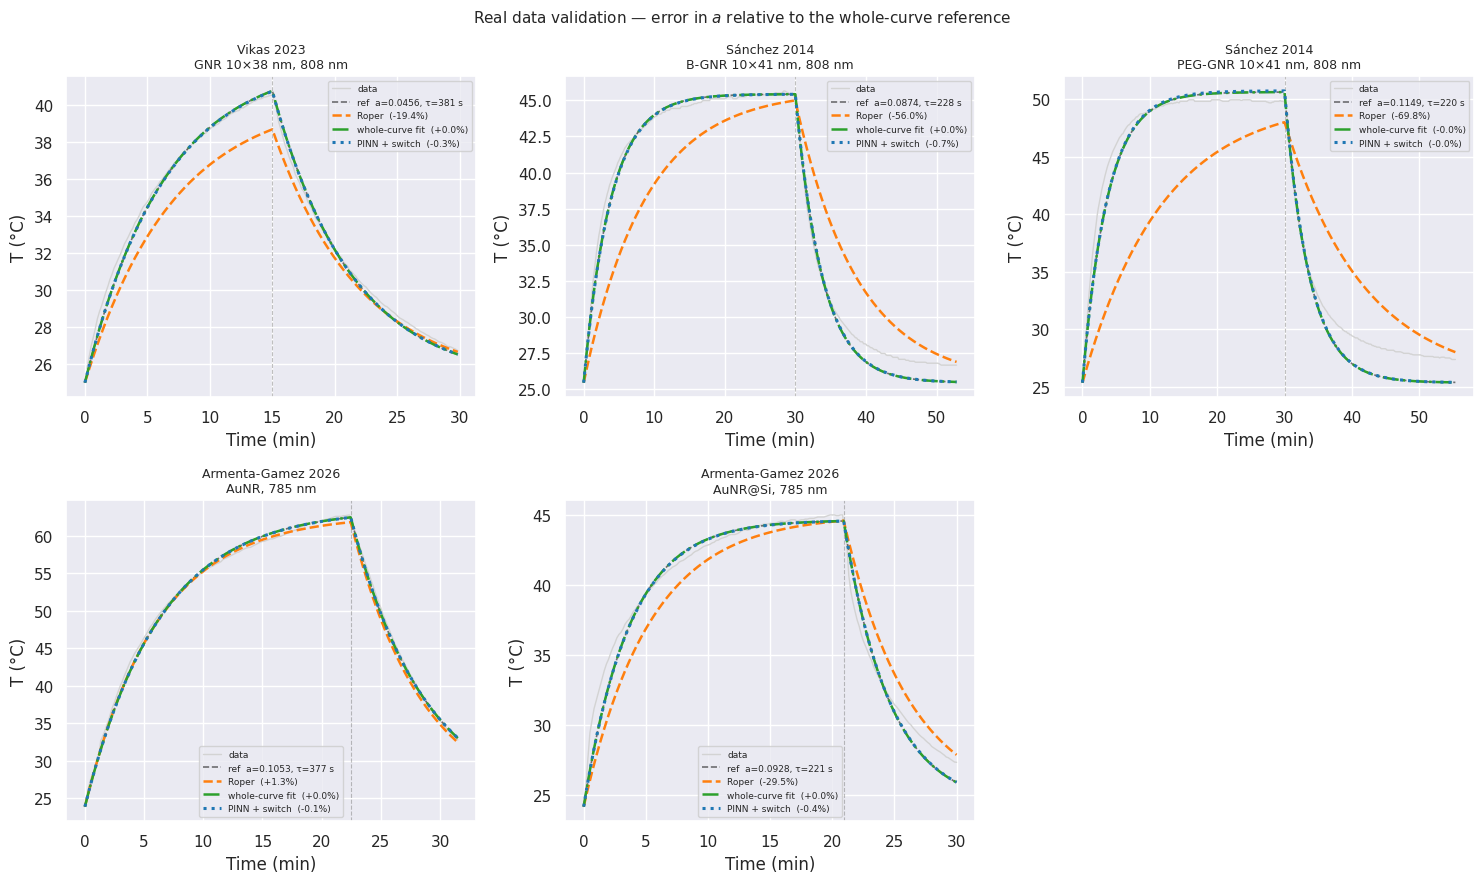

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

method_styles = {
    "Roper":           dict(color='tab:orange', ls='--', lw=1.8),
    "whole-curve fit": dict(color='tab:green',  ls='-.', lw=1.8),
    "PINN + switch":   dict(color='tab:blue',   ls=':',  lw=2.2),
}

for ax, (ds_name, ds) in zip(axes_flat, REAL_DATASETS.items()):
    t_r, T_r    = load_real(ds)
    t_off_r     = ds["t_off"]
    Tenv_r      = ds["Tenv"]
    ref_a, ref_tau = ds["ref_a"], ds["ref_tau"]
    tt = np.linspace(0, t_r.max(), 1000)

    ax.plot(t_r / 60, T_r, color='lightgray', lw=1.0, zorder=1, label='data')
    ax.plot(tt / 60, heating_cooling(tt, ref_a, ref_tau, t_off_r, Tenv_r),
            'k--', lw=1.2, alpha=0.6,
            label=f'ref  a={ref_a:.4f}, τ={ref_tau:.0f} s', zorder=2)

    for m_name, sty in method_styles.items():
        a_e, tau_e = real_fits[(ds_name, m_name)]
        da = 100 * (a_e - ref_a) / ref_a
        ax.plot(tt / 60, heating_cooling(tt, a_e, tau_e, t_off_r, Tenv_r),
                label=f'{m_name}  ({da:+.1f}%)', zorder=3, **sty)

    ax.axvline(t_off_r / 60, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('T (°C)')
    ax.set_title(ds_name.replace('\n', '\n'), fontsize=9)
    ax.legend(fontsize=6.5)

plt.suptitle('Real data validation — error in $a$ relative to the whole-curve reference', fontsize=11)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig4_real_data.jpg', dpi=150, bbox_inches='tight')
plt.show()

---
## 11 · Nonlinear Heat Loss: Learning the Loss Law

The single-τ ODE fits the real curves only approximately (Section 10). Their shape — a fast initial rise, a fast initial drop after switch-off, and a slow cooling tail — points to heat losses that grow faster than linearly with $\theta = T - T_{\mathrm{env}}$; laminar natural convection, for example, gives a heat flux $\propto \theta^{5/4}$. We therefore generalise the model to

$$\frac{d\theta}{dt} = a\,L(t) - f(\theta), \qquad f(0) = 0,$$

and compare four estimators of the heating rate $a$ (the quantity the PCE needs):

1. **Roper** — cooling-tail fit (assumes $f(\theta) = \theta/\tau$)
2. **Whole-curve single-τ fit** — Section 4 ($f(\theta) = \theta/\tau$)
3. **Power-law least squares** — $f(\theta) = k\,\theta^{n}$, fitted to the numerical ODE solution (multi-start in $n$). In the code it is parametrised as $f = k_{\mathrm{ref}}\,\theta_{\mathrm{ref}}\,(\theta/\theta_{\mathrm{ref}})^{n}$ with $\theta_{\mathrm{ref}} = \max\theta/2$, i.e. $k = k_{\mathrm{ref}}\,\theta_{\mathrm{ref}}^{\,1-n}$
4. **PINN with a learned loss law** — $f(\theta) = \theta\cdot\mathrm{softplus}(h_\phi(\theta))$, where $h_\phi$ is a small MLP (2 × 20 tanh) trained jointly with the temperature network and $a$; no functional form is assumed

$a$ stays identifiable for any $f$: at the same $\theta$, the heating slope minus the cooling slope equals $a$.

To compare the shape of $f$ across curves we use the **effective loss rate** $r(\theta) = f(\theta)/\theta$ (unit s$^{-1}$, equal to $1/\tau$ for a linear loss). It is not the scaled $\hat\kappa$ of Section 5, which exists only for the linear loss.

**`simulate_loss(t, a_, f, t_off_)`** — numerical solution of $d\theta/dt = a\,L(t) - f(\theta)$, $\theta(0) = 0$ (Section 11)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | times at which $\theta$ is returned (array) |
| `a_` | $a$ | °C/s | heating rate |
| `f` | $f$ | °C/s | heat-loss law, a function of $\theta$ in °C |
| `t_off_` | $t_{\mathrm{off}}$ | s | laser switch-off time |

**Returns:** the temperature rise $\theta(t)$ in °C.

In [20]:
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares


def simulate_loss(t, a_, f, t_off_):
    # numerical solution of dθ/dt = a L(t) - f(θ), θ(0) = 0
    rhs = lambda tt, y: [a_ * (tt < t_off_) - f(max(y[0], 0.0))]
    return solve_ivp(rhs, (0, t.max()), [0.0], t_eval=t, max_step=5.0, rtol=1e-8, atol=1e-10).y[0]

**`single_tau_fit(t, th, t_off_)`** — least-squares fit of the linear loss $f = k\theta$, with $k = 1/\tau$, to the numerical solution

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | measured times (array) |
| `th` | $\theta$ | °C | measured temperature rise $T - T_{\mathrm{env}}$ (array) |
| `t_off_` | $t_{\mathrm{off}}$ | s | laser switch-off time |

**Returns:** `([a, k], rms)` — heating rate (°C/s), $k = 1/\tau$ (s$^{-1}$), and the residual RMS (°C).

In [21]:
def single_tau_fit(t, th, t_off_):
    res = least_squares(lambda p: simulate_loss(t, p[0], lambda x: p[1] * x, t_off_) - th, [0.05, 3e-3],
                        bounds=([1e-5, 1e-6], [5, 1]), diff_step=1e-3, x_scale="jac")
    return res.x, np.sqrt(np.mean(res.fun ** 2))

**`power_law_fit(t, th, t_off_)`** — least-squares fit of $f = k_{\mathrm{ref}}\,\theta_{\mathrm{ref}}\,(\theta/\theta_{\mathrm{ref}})^{n}$ with $\theta_{\mathrm{ref}} = \max\theta/2$, equivalent to $f = k\,\theta^{n}$ with $k = k_{\mathrm{ref}}\,\theta_{\mathrm{ref}}^{\,1-n}$

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | measured times (array) |
| `th` | $\theta$ | °C | measured temperature rise (array) |
| `t_off_` | $t_{\mathrm{off}}$ | s | laser switch-off time |

**Returns:** `([a, k_ref, n], rms)` — heating rate (°C/s), $k_{\mathrm{ref}}$ (s$^{-1}$), exponent $n$, and the residual RMS (°C). Starting exponents: 0.8, 1, 1.3, 1.6, 2 (best fit kept).

In [22]:
def power_law_fit(t, th, t_off_):
    # f(θ) = k_ref·θref·(θ/θref)^n, i.e. k = k_ref·θref^(1-n); θref decorrelates k_ref and n, several starting exponents avoid local minima
    p_lin, _ = single_tau_fit(t, th, t_off_)
    ref, best = th.max() / 2, None
    for n0 in (0.8, 1.0, 1.3, 1.6, 2.0):
        res = least_squares(lambda p: simulate_loss(t, p[0], lambda x: p[1] * ref * (x / ref) ** p[2], t_off_) - th,
                            [p_lin[0], p_lin[1], n0], bounds=([1e-5, 1e-6, 0.3], [5, 1, 4]), diff_step=1e-3, x_scale="jac")
        if best is None or res.cost < best.cost:
            best = res
    return best.x, np.sqrt(np.mean(best.fun ** 2))

**`LossNet(n)`** — learned loss law $f(\theta) = \theta\cdot\mathrm{softplus}(h_\phi(\theta))$, with $\mathrm{softplus}(x) = \ln(1 + e^{x}) > 0$

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `n` | — | — | neurons per hidden layer of $h_\phi$ (default 20; 2 hidden layers, tanh) |

**Forward:** takes $\hat\theta$ of shape (N, 1) and returns $f$ (scaled) of shape (N, 1); $f = 0$ at $\theta = 0$.

In [23]:
class LossNet(nn.Module):
    # f(θ) = θ·softplus(h(θ)): zero at ambient temperature, positive above it
    def __init__(self, n=20):
        super().__init__()
        self.h = nn.Sequential(nn.Linear(1, n), nn.Tanh(), nn.Linear(n, n), nn.Tanh(), nn.Linear(n, 1))

    def forward(self, th):
        return th * nn.functional.softplus(self.h(th))

**`LossPINN(t_off_hat, n_units)`** — temperature network with the switch input, plus `loss_law` (a `LossNet`) and the learnable heating rate $\hat a$ (`a`)

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t_off_hat` | $\hat t_{\mathrm{off}}$ | — | scaled switch-off time, $t_{\mathrm{off}}/t_{\mathrm{scale}}$ |
| `n_units` | — | — | neurons per hidden layer of the temperature network (default 100; 4 hidden layers, tanh) |

**Forward:** takes $\hat t$ of shape (N, 1) and returns $\hat\theta$ of shape (N, 1).

In [24]:
class LossPINN(nn.Module):
    # temperature network with the switch input of Section 5, plus the learned loss law and the heating rate a
    def __init__(self, t_off_hat, n_units=100):
        super().__init__()
        self.t_off_hat = t_off_hat
        layers, d = [], 2
        for _ in range(4):
            layers += [nn.Linear(d, n_units), nn.Tanh()]
            d = n_units
        self.body = nn.Sequential(*layers, nn.Linear(n_units, 1))
        self.loss_law = LossNet()
        self.a = nn.Parameter(torch.tensor([1.0]))

    def forward(self, t):
        return self.body(torch.cat([t, torch.relu(t - self.t_off_hat)], dim=1))

**`train_loss_pinn(t, th, t_off_, adam_epochs, lbfgs_iters, lam, seed, n_units)`** — trains `LossPINN` with data + ODE residual $\hat a\,L - f(\hat\theta) - d\hat\theta/d\hat t$ + initial condition

| Parameter | Symbol | Unit | Meaning |
|---|---|---|---|
| `t` | $t$ | s | measured times (array) |
| `th` | $\theta$ | °C | measured temperature rise $T - T_{\mathrm{env}}$ (array) |
| `t_off_` | $t_{\mathrm{off}}$ | s | laser switch-off time |
| `adam_epochs`, `lbfgs_iters` | — | — | Adam steps (8000) and L-BFGS iterations (1000) |
| `lam` | $\lambda$ | — | weight of the physics terms (default 1) |
| `seed` | — | — | random seed for the weights |
| `n_units` | — | — | width of the four hidden layers of the temperature network (default 100) |

**Returns:** `(a_est, f_est, fit)` — heating rate (°C/s), a function `f_est(theta)` giving the learned loss $f$ in °C/s for $\theta$ in °C, and the fitted $\theta$ at the data times (°C).

In [25]:
def train_loss_pinn(t, th, t_off_, adam_epochs=8000, lbfgs_iters=1000, lam=1.0, seed=0, n_units=100):
    torch.manual_seed(seed)
    t_scale, T_scale = float(t.max()), float(th.max())
    t_hat = np_to_th(t / t_scale); theta_hat = np_to_th(th / T_scale)
    model = LossPINN(t_off_ / t_scale, n_units=n_units).to(DEVICE)
    t_col = torch.linspace(0, 1, 800).view(-1, 1).to(DEVICE).requires_grad_(True)
    laser = (t_col < t_off_ / t_scale).float()

    def total_loss():
        th_c = model(t_col)
        dth = grad(th_c, t_col)[0]
        res = dth - model.a * laser + model.loss_law(th_c)
        ic = model(torch.zeros(1, 1).to(DEVICE)).pow(2).mean()
        return ((model(t_hat) - theta_hat) ** 2).mean() + lam * ((res ** 2).mean() + ic)

    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for _ in range(adam_epochs):
        opt.zero_grad(); l = total_loss(); l.backward(); opt.step()
    opt2 = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iters, line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); l = total_loss(); l.backward(); return l
    opt2.step(closure)

    a_est = model.a.item() * T_scale / t_scale
    f_est = lambda x: model.loss_law(np_to_th(np.atleast_1d(x) / T_scale)).detach().cpu().numpy().ravel() * T_scale / t_scale
    fit = model(t_hat).detach().cpu().numpy().ravel() * T_scale
    return a_est, f_est, fit

### 11.1 Synthetic check with a known loss law

Same $a = 0.05$ °C/s and 0.1 °C noise as before, with two nonlinear loss laws of similar strength: a pure power law $f = k\theta^{1.25}$ (steady state at 20 °C) and a mixed law $f = k_1\theta + k_2\theta^2$ that no single power law represents exactly. Heating lasts 600 s or 1200 s and cooling as long again; three noise seeds per case.

In [26]:
# a_true (heating rate) is the global defined in Section 3
LOSS_LAWS = {
    "power n=1.25":     lambda x: (0.05 / 20 ** 1.25) * np.maximum(x, 0) ** 1.25,
    "linear+quadratic": lambda x: 1.25e-3 * np.maximum(x, 0) + 6.25e-5 * np.maximum(x, 0) ** 2,
}
rows3 = []
for law, f_true in LOSS_LAWS.items():
    for t_off_ in (600.0, 1200.0):
        for seed_ in range(3):
            rng = np.random.default_rng(10 * seed_ + int(t_off_))
            t_ = np.arange(0, 2 * t_off_ + 1, 10.0)
            th_ = simulate_loss(t_, a_true, f_true, t_off_) + rng.normal(0, 0.1, t_.size)
            a_r, _ = roper(t_, th_ + Tenv_true, t_off_)
            p_s, rms_s = single_tau_fit(t_, th_, t_off_)
            p_p, rms_p = power_law_fit(t_, th_, t_off_)
            a_n, f_n, fit_n = train_loss_pinn(t_, th_, t_off_, seed=seed_)
            grid_ = np.linspace(1, th_.max(), 30)
            rows3.append(dict(law=law, t_off=t_off_, seed=seed_,
                              Roper=100 * (a_r - a_true) / a_true, single_tau=100 * (p_s[0] - a_true) / a_true,
                              power_law=100 * (p_p[0] - a_true) / a_true, loss_PINN=100 * (a_n - a_true) / a_true,
                              n_power=p_p[2], rms_single=rms_s, rms_power=rms_p,
                              rms_PINN=np.sqrt(np.mean((fit_n - th_) ** 2)),
                              f_err_pct=100 * np.max(np.abs(f_n(grid_) - f_true(grid_))) / f_true(th_.max())))

df3 = pd.DataFrame(rows3)
df3.to_csv("results/loss_law_synthetic.csv", index=False)
cols = ["Roper", "single_tau", "power_law", "loss_PINN", "n_power", "rms_single", "rms_power", "rms_PINN", "f_err_pct"]
print("=== Error in a [%], fitted exponent, RMS [°C], max error of the learned f [%] (mean over 3 seeds) ===")
print(df3.groupby(["law", "t_off"])[cols].mean().round(2).to_string())
print("\n=== Standard deviation over seeds ===")
print(df3.groupby(["law", "t_off"])[["Roper", "single_tau", "power_law", "loss_PINN"]].std().round(2).to_string())

=== Error in a [%], fitted exponent, RMS [°C], max error of the learned f [%] (mean over 3 seeds) ===
                         Roper  single_tau  power_law  loss_PINN  n_power  rms_single  rms_power  rms_PINN  f_err_pct
law              t_off                                                                                               
linear+quadratic 600.0  -37.37        1.12      -0.16      -0.25     1.36        0.31       0.10      0.10       2.83
                 1200.0 -33.75       -2.54       0.24       0.34     1.36        0.73       0.12      0.11       1.46
power n=1.25     600.0  -33.42        1.02       0.15      -0.14     1.26        0.25       0.10      0.10       2.48
                 1200.0 -28.63       -1.88      -0.05       0.35     1.25        0.53       0.10      0.12       1.55

=== Standard deviation over seeds ===
                         Roper  single_tau  power_law  loss_PINN
law              t_off                                          
linear+quadratic 600.

### 11.2 Real curves

The same estimators on the five digitised curves. The learned loss law is reported as the effective relaxation rate $r(\theta) = f(\theta)/\theta$ ($= 1/\tau$ for a linear loss); three training seeds show how stable the PINN estimate is. Labels: DS1 = Vikas 2023, DS2a/DS2b = Sánchez 2014 bare/PEG-GNR, DS3/DS4 = Armenta-Gamez 2026 AuNR/AuNR@Si.

a in °C/s; RMS in °C; r_ratio = r(0.9 θmax) / r(0.2 θmax) of the learned law (1 for a linear loss)
                              dataset  a_single  a_power  n_power  a_PINN  a_PINN_sd  rms_single  rms_power  rms_PINN  r_ratio
      Vikas 2023 GNR 10×38 nm, 808 nm   0.04562  0.04605     1.18 0.04605    0.00002        0.36       0.24      0.23     1.37
  Sánchez 2014 B-GNR 10×41 nm, 808 nm   0.08740  0.09072     1.31 0.09248    0.00051        0.78       0.43      0.29     1.77
Sánchez 2014 PEG-GNR 10×41 nm, 808 nm   0.11487  0.12708     1.62 0.12823    0.00026        1.64       0.44      0.29     2.90
      Armenta-Gamez 2026 AuNR, 785 nm   0.10533  0.10516     1.01 0.10455    0.00022        0.57       0.57      0.46     1.34
   Armenta-Gamez 2026 AuNR@Si, 785 nm   0.09278  0.09388     1.24 0.09661    0.00014        0.97       0.83      0.68     2.77


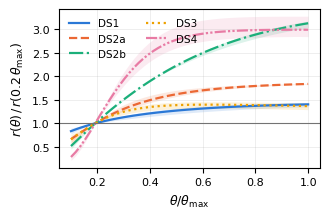

In [27]:
rows4, loss_curves = [], {}
for ds_name, ds in REAL_DATASETS.items():
    t_r, T_r = load_real(ds)
    th_r, t_off_r = T_r - ds["Tenv"], ds["t_off"]
    p_s, rms_s = single_tau_fit(t_r, th_r, t_off_r)
    p_p, rms_p = power_law_fit(t_r, th_r, t_off_r)
    runs = [train_loss_pinn(t_r, th_r, t_off_r, seed=s) for s in range(3)]
    a_runs = np.array([r[0] for r in runs])
    rms_runs = np.array([np.sqrt(np.mean((r[2] - th_r) ** 2)) for r in runs])
    grid_ = np.linspace(0.1, 1.0, 50) * th_r.max()
    loss_curves[ds_name] = (grid_ / th_r.max(), np.array([r[1](grid_) / grid_ for r in runs]))
    rows4.append(dict(dataset=ds_name.replace("\n", " "),
                      a_single=round(p_s[0], 5), a_power=round(p_p[0], 5), n_power=round(p_p[2], 2),
                      a_PINN=round(a_runs.mean(), 5), a_PINN_sd=round(a_runs.std(ddof=1), 5),
                      rms_single=round(rms_s, 2), rms_power=round(rms_p, 2), rms_PINN=round(rms_runs.mean(), 2),
                      r_ratio=round(np.mean([r[1](np.array([0.9 * th_r.max()]))[0] / r[1](np.array([0.2 * th_r.max()]))[0] * 0.2 / 0.9 for r in runs]), 2)))

df4 = pd.DataFrame(rows4)
df4.to_csv("results/loss_law_real.csv", index=False)
print("a in °C/s; RMS in °C; r_ratio = r(0.9 θmax) / r(0.2 θmax) of the learned law (1 for a linear loss)")
print(df4.to_string(index=False))

# learned r(θ) normalised at 0.2 θmax, per curve (mean and range over the three seeds), saved for re-plotting
DS_LABELS = ["DS1", "DS2a", "DS2b", "DS3", "DS4"]
curve_rows = []
for label, (x, r_runs) in zip(DS_LABELS, loss_curves.values()):
    r_norm = r_runs / r_runs[:, [np.argmin(np.abs(x - 0.2))]]
    curve_rows.append(pd.DataFrame({"dataset": label, "theta_over_max": x, "r_mean": r_norm.mean(axis=0),
                                    "r_min": r_norm.min(axis=0), "r_max": r_norm.max(axis=0)}))
df_curves = pd.concat(curve_rows)
df_curves.to_csv("results/loss_law_curves.csv", index=False)

# fixed categorical order (validated reference palette) plus distinct line styles for black-and-white print
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
STYLES = ["-", "--", "-.", ":", (0, (5, 1, 1, 1, 1, 1))]
with plt.style.context("default"):
    fig, ax = plt.subplots(figsize=(3.4, 2.3))
    for (label, d), color, ls in zip(df_curves.groupby("dataset", sort=False), COLORS, STYLES):
        ax.fill_between(d.theta_over_max, d.r_min, d.r_max, color=color, alpha=0.15, lw=0)
        ax.plot(d.theta_over_max, d.r_mean, color=color, ls=ls, lw=1.6, label=label)
    ax.axhline(1, color="0.45", lw=0.8)
    ax.set_xlabel(r"$\theta / \theta_{\max}$", fontsize=9)
    ax.set_ylabel(r"$r(\theta)\,/\,r(0.2\,\theta_{\max})$", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3, lw=0.5)
    ax.legend(fontsize=7.5, frameon=False, ncol=2, loc="upper left")
    fig.tight_layout()
    os.makedirs("results/plots", exist_ok=True)
    fig.savefig("results/plots/fig5_learned_loss_law.jpg", dpi=200, bbox_inches="tight")
    fig.savefig("results/plots/fig5_learned_loss_law.pdf", bbox_inches="tight")
    plt.show()


### 11.3 Observations

1. **Synthetic data.** With a nonlinear loss, Roper misses $a$ by −29 % to −34 % even for 1200 s of heating (−33 % to −37 % for 600 s), and the single-exponential fit by up to −2.5 %. The power-law fit and the learned-loss PINN both recover $a$ within 0.4 %; the learned law matches the true $f$ within 2.9 %, while the power law can describe the mixed law only through an effective exponent of 1.36.
2. **Real data — residual.** The learned loss law gives the lowest residual on all five curves: 0.23–0.68 °C, against 0.36–1.64 °C for the single exponential and 0.24–0.83 °C for the power law (19–82 % below the single-exponential misfit).
3. **Real data — shape of the loss.** The effective loss rate $r(\theta) = f(\theta)/\theta$ grows with temperature on every curve ($r(0.9\,\theta_{\max}) / r(0.2\,\theta_{\max})$ = 1.34–2.90). Three curves give power-law exponents of 1.18–1.31, close to laminar natural convection ($n = 5/4$); DS2b gives 1.62 and DS3 1.01.
4. **Real data — heating rate.** The learned-loss $a$ differs from the single-exponential one by −0.7 % to +11.6 %; the three largest changes (+5.8 %, +4.1 %, +11.6 %) are on the three most nonlinear curves (DS2a, DS4, DS2b). The spread over three seeds is at most 0.6 % (DS2a). DS4 is not well determined (point 6).
5. **Caveat.** The learned $f$ is an *effective* loss law: besides convection and radiation it can absorb sensor effects, such as the fast transients at switch-on and switch-off in Armenta-Gamez Fig. 4A.
6. **DS4 is not well determined (Section 11.5).** Over 15 runs (widths 20, 50, 100; five seeds) the change of $a$ relative to the single exponential spans +2.1 % to +14.0 %: 11 runs give < 5 %, one +5.0 %, one +8.3 %, two +13 % to +14 %. The correlation between the ODE misfit and the change is −0.98, and the run with the lowest misfit (0.53 °C) gives +13.2 %, so the reported mean of three seeds (+4.1 %) is not reliable.
7. **Held-out extrapolation (Section 11.4).** The learned law predicts the held-out cooling tail better than the power-law fit on DS2a, DS2b and DS4 (0.23, 0.12, 0.75 °C against 0.73, 0.82, 1.60 °C; seed SD 0.13, 0.03, 0.71 °C) and worse on DS1 and DS3 (0.92 and 1.96 °C against 0.19 and 0.61 °C). Its advantage therefore holds only for strongly nonlinear curves; why it fails on the others was not tested.

### 11.4 Held-out extrapolation

A lower residual on the fitted data does not prove that a loss law is correct, since a more flexible model also fits noise better. For each curve, every method is therefore trained on the heating phase and the first half of the cooling phase only, and the second half of the cooling phase is predicted by integrating the ODE with the fitted $a$ and loss law (the PINN's collocation points also stay inside the training window). The table gives the RMS error on the held-out points in °C (the PINN over three seeds), saved in `results/loss_law_extrapolation.csv`.

**Result.** The learned law gives a smaller held-out error than the power-law fit on DS2a, DS2b and DS4 (0.23, 0.12, 0.75 °C against 0.73, 0.82, 1.60 °C) and a larger one on DS1 and DS3 (0.92 and 1.96 °C against 0.19 and 0.61 °C); the single exponential gives 0.55, 1.25, 2.35, 0.22 and 1.81 °C on DS1, DS2a, DS2b, DS3, DS4.

In [28]:
# Section 11.4: train on heating + first half of cooling, predict the second half of cooling
rows5 = []
for ds_name, ds in REAL_DATASETS.items():
    t_r, T_r = load_real(ds)
    th_r, t_off_r = T_r - ds["Tenv"], ds["t_off"]
    cut = t_off_r + 0.5 * (t_r.max() - t_off_r)
    fit, held = t_r <= cut, t_r > cut
    rms_held = lambda y: np.sqrt(np.mean((y[held] - th_r[held]) ** 2))

    p_s, _ = single_tau_fit(t_r[fit], th_r[fit], t_off_r)
    p_p, _ = power_law_fit(t_r[fit], th_r[fit], t_off_r)
    ref = th_r[fit].max() / 2                                   # theta_ref used inside power_law_fit
    y_s = simulate_loss(t_r, p_s[0], lambda x: p_s[1] * x, t_off_r)
    y_p = simulate_loss(t_r, p_p[0], lambda x: p_p[1] * ref * (x / ref) ** p_p[2], t_off_r)

    rms_pinn = []
    for seed_ in range(3):
        a_n, f_n, _ = train_loss_pinn(t_r[fit], th_r[fit], t_off_r, seed=seed_)
        y_n = simulate_loss(t_r, a_n, lambda x: float(f_n(np.array([x]))[0]), t_off_r)
        rms_pinn.append(rms_held(y_n))

    rows5.append(dict(dataset=ds_name.replace("\n", " "), n_fit=int(fit.sum()), n_held=int(held.sum()),
                      rms_single=rms_held(y_s), rms_power=rms_held(y_p),
                      rms_PINN=np.mean(rms_pinn), rms_PINN_sd=np.std(rms_pinn, ddof=1)))

df5 = pd.DataFrame(rows5)
df5.to_csv("results/loss_law_extrapolation.csv", index=False)
print("RMS error on the held-out cooling tail [°C]")
print(df5.round(2).to_string(index=False))

RMS error on the held-out cooling tail [°C]
                              dataset  n_fit  n_held  rms_single  rms_power  rms_PINN  rms_PINN_sd
      Vikas 2023 GNR 10×38 nm, 808 nm    134      45        0.55       0.19      0.92         0.11
  Sánchez 2014 B-GNR 10×41 nm, 808 nm    245      69        1.25       0.73      0.23         0.13
Sánchez 2014 PEG-GNR 10×41 nm, 808 nm    255      77        2.35       0.82      0.12         0.03
      Armenta-Gamez 2026 AuNR, 785 nm    162      28        0.22       0.61      1.96         0.11
   Armenta-Gamez 2026 AuNR@Si, 785 nm    153      28        1.81       1.60      0.75         0.71


### 11.5 Is the heating rate of DS4 well determined?

On DS4 the learned loss law can end in different solutions. Here the same curve is trained with three network widths and five seeds each. `da_vs_single_pct` is the change of the learned $a$ relative to the single-exponential fit, `rms_ode` the RMS misfit of the ODE solution with the learned $a$ and $f$, and `rms_network` the RMS misfit of the temperature network itself. The table is saved in `results/loss_law_ds4_sensitivity.csv`.

**Result.** `da_vs_single_pct` spans +2.1 % to +14.0 %, and it falls as the misfit falls (correlation of `rms_ode` with `da_vs_single_pct`: −0.98); the lowest misfit (0.53 °C) gives +13.2 %.

In [29]:
# Section 11.5: DS4 with several network widths and seeds
ds4_name, ds4 = list(REAL_DATASETS.items())[-1]
t_r, T_r = load_real(ds4)
th_r, t_off_r = T_r - ds4["Tenv"], ds4["t_off"]
p_s, _ = single_tau_fit(t_r, th_r, t_off_r)

rows6 = []
for n_units_ in (20, 50, 100):
    for seed_ in range(5):
        a_n, f_n, fit_n = train_loss_pinn(t_r, th_r, t_off_r, seed=seed_, n_units=n_units_)
        y_n = simulate_loss(t_r, a_n, lambda x: float(f_n(np.array([x]))[0]), t_off_r)
        rows6.append(dict(n_units=n_units_, seed=seed_, a=a_n,
                          da_vs_single_pct=100 * (a_n - p_s[0]) / p_s[0],
                          rms_network=np.sqrt(np.mean((fit_n - th_r) ** 2)),
                          rms_ode=np.sqrt(np.mean((y_n - th_r) ** 2))))

df6 = pd.DataFrame(rows6)
df6.to_csv("results/loss_law_ds4_sensitivity.csv", index=False)
print(ds4_name.replace("\n", " "), "| single-exponential a =", round(p_s[0], 5), "°C/s")
print(df6.round(4).to_string(index=False))

Armenta-Gamez 2026 AuNR@Si, 785 nm | single-exponential a = 0.09278 °C/s
 n_units  seed      a  da_vs_single_pct  rms_network  rms_ode
      20     0 0.1058           14.0356       0.5298   0.5351
      20     1 0.0951            2.5005       0.7110   0.7215
      20     2 0.0958            3.2563       0.7066   0.7157
      20     3 0.0956            3.0667       0.7110   0.7207
      20     4 0.0948            2.1375       0.7164   0.7281
      50     0 0.0954            2.7849       0.7154   0.7259
      50     1 0.1005            8.2893       0.5754   0.5854
      50     2 0.0962            3.6526       0.6827   0.6926
      50     3 0.1050           13.1648       0.5208   0.5267
      50     4 0.0962            3.6616       0.6944   0.7037
     100     0 0.0968            4.2942       0.6776   0.6864
     100     1 0.0965            3.9973       0.6766   0.6874
     100     2 0.0966            4.0871       0.6870   0.6957
     100     3 0.0952            2.5851       0.7200   0.73

---
## 12 · Summary

| Finding | Value |
|---|---|
| Roper error at $t_{\mathrm{off}}/\tau = 0.5$ | −61.2 % |
| Roper error at $t_{\mathrm{off}}/\tau = 1$ | −36.5 % |
| Roper error at $t_{\mathrm{off}}/\tau = 2$ | −14.6 % |
| Roper error at $t_{\mathrm{off}}/\tau = 5$ | +0.8 % |
| Whole-curve fit mean error (synthetic sweep) | ≤ 0.2 % |
| PINN + switch mean error (synthetic sweep) | ≤ 0.2 % |
| PINN without switch input (five seeds) | −29.3 % to +10.0 % at $t_{\mathrm{off}}/\tau = 5$, −6.3 % to +0.14 % at $t_{\mathrm{off}}/\tau = 1$; with switch ≤ 0.7 % |
| Real data: Roper vs whole-curve fit, error in $a$ | −69.8 % to +1.3 % |
| Real data: PINN vs whole-curve fit | within 0.7 % in $a$, ≤ 0.6 % in $\tau$ |
| Real data: single-τ ODE misfit (whole-curve RMS) | 0.36–1.64 °C |
| Nonlinear loss (synthetic): Roper error in $a$ | −29 % to −37 % |
| Nonlinear loss (synthetic): learned-loss PINN, error in $a$ / in $f$ | ≤ 0.4 % / ≤ 2.9 % |
| Real data: residual of single-τ / power law / learned loss | 0.36–1.64 / 0.24–0.83 / 0.23–0.68 °C |
| Real data: learned-loss $a$ vs single-τ $a$ | −0.7 % to +11.6 % (seed spread ≤ 0.6 %) |
| Real data: DS4, learned-loss $a$ vs single-τ $a$ (15 runs) | +2.1 % to +14.0 % |
| Real data: held-out cooling tail, learned loss vs power law | better on DS2a, DS2b, DS4; worse on DS1, DS3 |

**Key takeaways:**

1. On synthetic data the Roper error is the heating-truncation factor $1 - e^{-t_{\mathrm{off}}/\tau}$ of Section 2: it is negative whenever the heating phase is shorter than ≈ 3τ (−61.2 % at $t_{\mathrm{off}}/\tau = 0.5$) and vanishes for long experiments.
2. Both the whole-curve least-squares fit and the PINN remove this bias by fitting the complete ODE solution to heating and cooling simultaneously (errors ≤ 0.2 %).
3. The switch input $[t,\,\mathrm{ReLU}(t-t_{\mathrm{off}})]$ is essential for the PINN: without it the error in $a$ over five seeds spans −29.3 % to +10.0 % (long) and −6.3 % to +0.14 % (short), with it every run stays within 0.7 %.
4. On the five real curves (Vikas 2023, Sánchez 2014, Armenta-Gamez 2026) the single-τ ODE fits only approximately (whole-curve RMS 0.36–1.64 °C). In four of the five curves the cooling phase alone gives a longer relaxation time than the complete trace (e.g. 709 s against 220 s for PEG-GNR), because the cooling tails stay above the initial baseline, so the Roper estimate of $a$ falls 19–70 % below the whole-curve value; only AuNR agrees (+1.3 %).
5. The linear-loss PINN agrees with the whole-curve fit to within 0.7 % in $a$ and 0.6 % in $\tau$ on all real curves, so it offers no accuracy advantage over least squares in the single-τ setting.
6. Section 11 shows where the PINN adds value: once the loss law is unknown, it learns $f(\theta)$ from the data, recovers $a$ within 0.4 % on synthetic data, and gives the lowest residual on all five real curves; out of sample its advantage holds only for the strongly nonlinear curves (Section 11.4), and the heating rate of DS4 is not well determined (Section 11.5). The real curves lose heat faster than linearly (power-law exponents 1.18–1.31 on three curves, close to natural convection), which also explains the large Roper errors on real data.